<a href="https://colab.research.google.com/github/SudabathulaTejaswi/heart-disease-prediction-using-shap-/blob/main/4_2_project_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier

import shap


In [ ]:
data = pd.read_csv("heart.csv")
print(data.shape)
print(data.info())
print(data.isnull().sum())
print(data.duplicated().sum())


(918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak

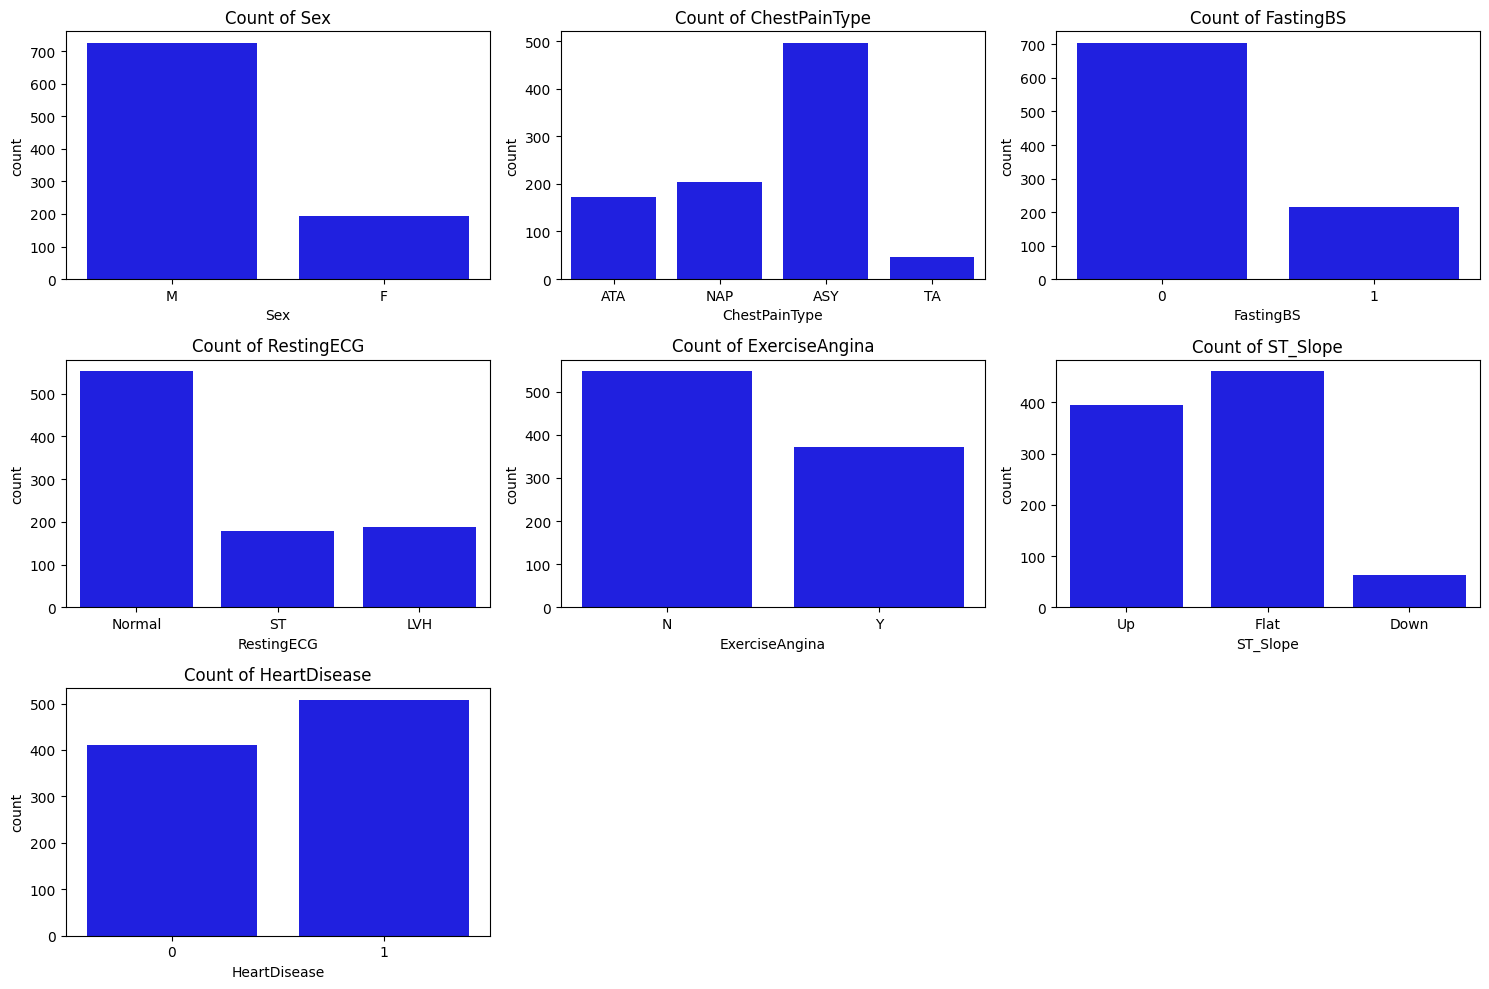

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
data = pd.read_csv("heart.csv")

# List of categorical and numerical columns
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# -----------------------------
# Plot categorical columns
# -----------------------------
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=col, data=data, color='blue')
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.show()


In [ ]:
data_encoded = pd.get_dummies(
    data,
    columns=["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"],
    drop_first=True
)


In [ ]:
X = data_encoded.drop("HeartDisease", axis=1)
y = data_encoded["HeartDisease"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        random_state=42
    )
}


In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, y_pred)

comparison = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
print(comparison)


                     Accuracy
Logistic Regression  0.885870
Decision Tree        0.788043
Random Forest        0.875000
AdaBoost             0.891304
Gradient Boosting    0.875000
XGBoost              0.875000


In [ ]:
best_model = models["XGBoost"]

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


Accuracy: 0.875
ROC AUC: 0.9330463892874222
              precision    recall  f1-score   support

           0       0.85      0.88      0.86        82
           1       0.90      0.87      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



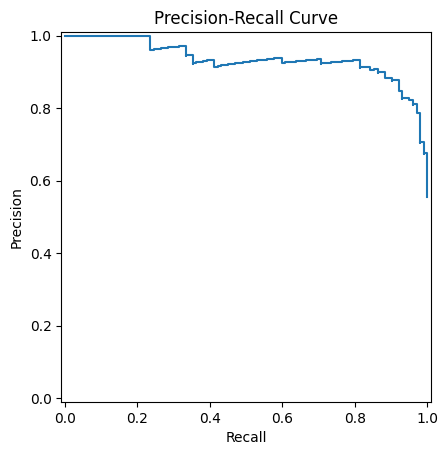

In [ ]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Ensure best_model is defined in this scope
best_model = models["XGBoost"]

# Ensure y_prob is defined before plotting
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_prob);

disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.title("Precision-Recall Curve")
plt.show()

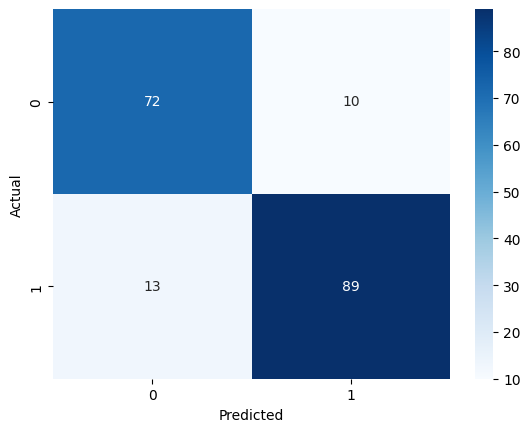

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


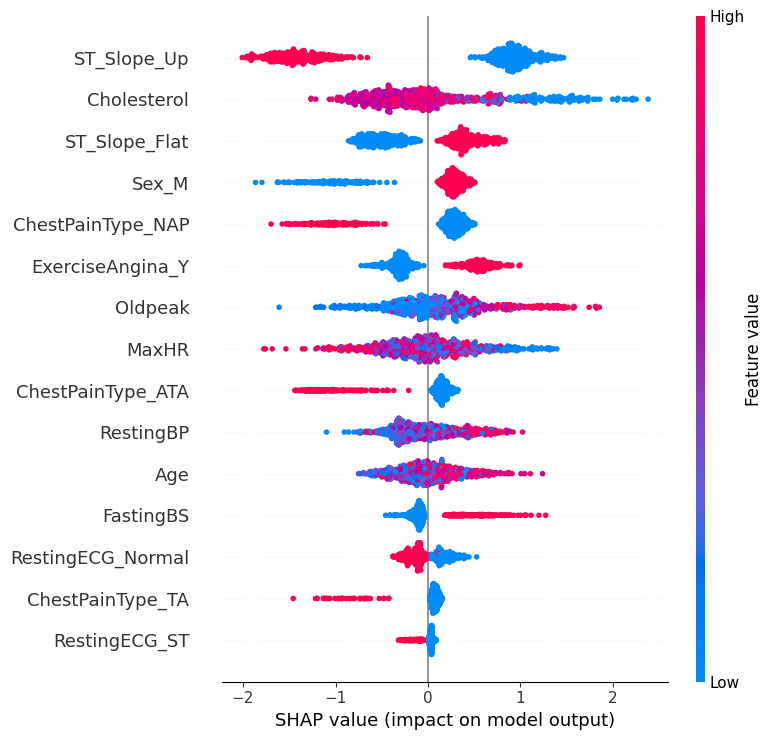

In [ ]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train_scaled)

shap.summary_plot(shap_values, X_train, feature_names=X.columns)

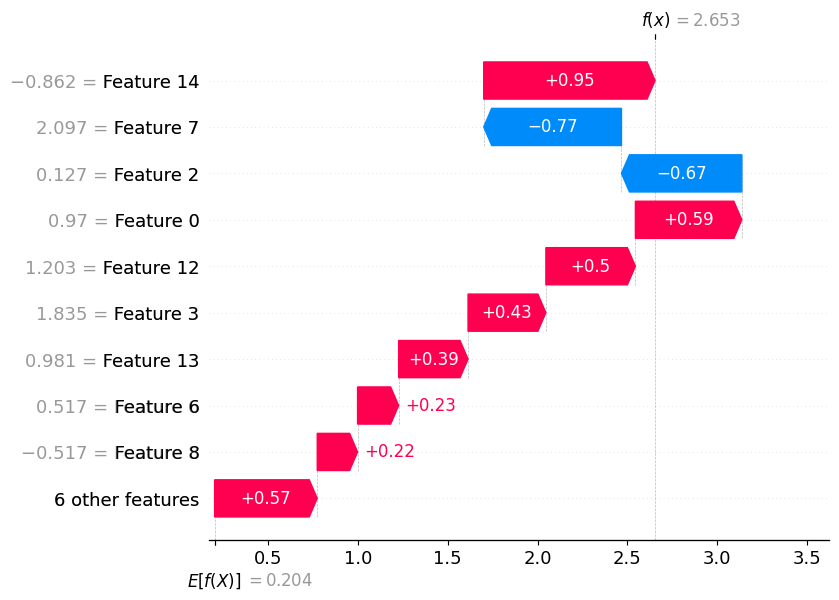

In [ ]:
shap.plots.waterfall(shap_values[0])

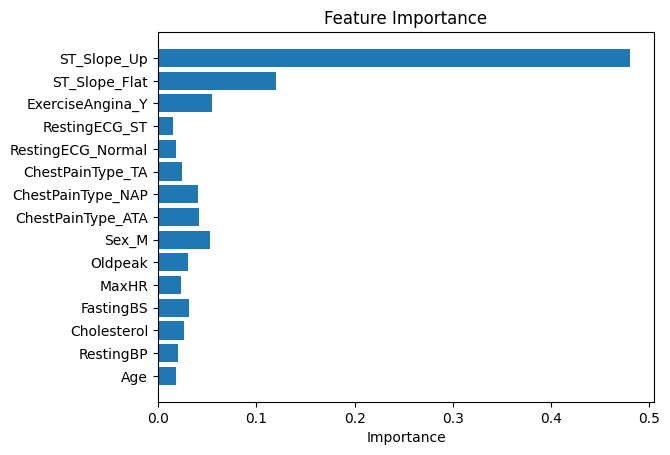

In [ ]:
importance = best_model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

final_results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Some models don't support predict_proba (safety check)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None

    acc = accuracy_score(y_test, y_pred)

    final_results.append([name, acc, roc_auc])

# Create DataFrame
final_df = pd.DataFrame(
    final_results,
    columns=["Model", "Accuracy", "ROC-AUC"]
)

# Mark selected model (XGBoost)
final_df["Selected"] = final_df["Model"].apply(
    lambda x: "Yes" if x == "XGBoost" else "No"
)

# Sort by ROC-AUC (recommended in medical ML)
final_df = final_df.sort_values(by="ROC-AUC", ascending=False)

final_df


,Model,Accuracy,ROC-AUC,Selected
5,XGBoost,0.875000,0.933046,Yes
4,Gradient Boosting,0.875000,0.932329,No
2,Random Forest,0.875000,0.931731,No
0,Logistic Regression,0.885870,0.929699,No
3,AdaBoost,0.891304,0.917324,No
1,Decision Tree,0.788043,0.781325,No


Although Logistic Regression demonstrated strong baseline performance and high interpretability, it assumes linear and independent relationships among clinical variables, which may not adequately capture the complex interactions inherent in cardiovascular disease. In contrast, XGBoost is capable of modeling non-linear patterns and higher-order feature interactions that more closely reflect real-world clinical decision-making. Moreover, XGBoost achieved superior discriminative performance in terms of ROC-AUC while maintaining comparable accuracy. The integration of SHAP further addresses interpretability concerns by providing transparent, patient-level explanations of model predictions. Therefore, XGBoost was selected as the final predictive model due to its balance of predictive strength, robustness, and explainability, making it more suitable for clinical decision support systems.”